### **Customer Segmentation Using AI in Python**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#  SECTION 1 — EXPLORATORY DATA ANALYSIS

In [ ]:
#  Goal: Understand the dataset before building any model.
#
#  DATASET COLUMNS:
#    customer_id        – unique customer code  (C0001 … C0500)
#    age                – customer age  (18–70)
#    annual_income      – yearly income in USD
#    spending_score     – mall spending score  (1–100)
#    purchase_freq      – number of purchases per year
#    avg_order_value    – average order amount in USD
#    loyalty_years      – how many years the person has been a customer
#    online_ratio       – share of purchases made online  (0–1)
#    returns_rate       – share of orders returned  (0–0.5)
#    region             – North / South / East / West
#    gender             – Male / Female / Other
#    preferred_category – favourite product category

Shape of dataset: (500, 12)

Data types and columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    object 
 1   age                 500 non-null    int64  
 2   annual_income       500 non-null    float64
 3   spending_score      500 non-null    int64  
 4   purchase_freq       500 non-null    int64  
 5   avg_order_value     500 non-null    float64
 6   loyalty_years       500 non-null    int64  
 7   online_ratio        500 non-null    float64
 8   returns_rate        500 non-null    float64
 9   region              500 non-null    object 
 10  gender              500 non-null    object 
 11  preferred_category  500 non-null    object 
dtypes: float64(4), int64(4), object(4)
memory usage: 47.0+ KB
None

First 5 rows:
  customer_id  age  annual_income  spending_score  purchase_freq  \
0    

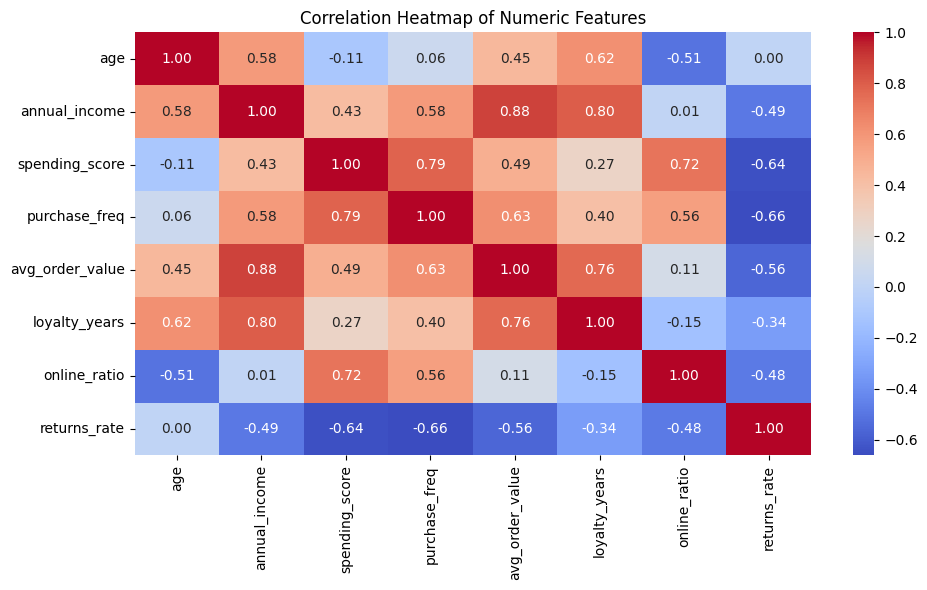

In [ ]:
# 1.1
df = pd.read_csv("customer_data.csv")

print("Shape of dataset:", df.shape)
print("\nData types and columns:")
print(df.info())

print("\nFirst 5 rows:")
print(df.head())


# 1.2
# descriptive statistics (count, mean, std, min, 25%, 50%, 75%, max)
print("\nDescriptive statistics for numeric columns:")
print(df.describe())


# 1.3
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

if missing_values.sum() == 0:
    print("\nThe dataset is clean: no missing values found.")


# 1.4
print("\nCustomer count by region:")
print(df["region"].value_counts())

print("\nCustomer count by gender:")
print(df["gender"].value_counts())


# 1.5
numeric_features = ['age', 'annual_income', 'spending_score',
                    'purchase_freq', 'avg_order_value', 'loyalty_years',
                    'online_ratio', 'returns_rate']

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png")
plt.show()

In [ ]:
#  SECTION 2 — DATA PREPROCESSING

In [ ]:
#  Goal: Prepare a clean, scaled feature matrix ready for K-Means.
#
#  Why scale?
#  K-Means measures distance between points.  Without scaling, annual_income (range 20 000–150 000) would completely overpower spending_score (1–100).
#  StandardScaler transforms every feature to mean = 0, std = 1.

In [ ]:
# 2.1
feature_cols = [
    'age',
    'annual_income',
    'spending_score',
    'purchase_freq',
    'avg_order_value',
    'loyalty_years',
    'online_ratio',
    'returns_rate'
]

X = df[feature_cols]
print("Shape of X:", X.shape)


# 2.2
# Scale  X  using  StandardScaler.
# Store:
#   scaler   – the fitted StandardScaler object
#   X_scaled – the resulting numpy array  (same shape as X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 2.3
# the mean and standard deviation of each column:
#   BEFORE scaling  (from X)
#   AFTER  scaling  (from X_scaled)
print("\nBEFORE scaling:")
print("Means:")
print(X.mean())
print("\nStandard deviations:")
print(X.std())

print("\nAFTER scaling:")
print("Means:")
print(pd.DataFrame(X_scaled, columns=feature_cols).mean())
print("\nStandard deviations:")
print(pd.DataFrame(X_scaled, columns=feature_cols).std())



# 2.4
# Store:
#   pca   – the fitted PCA object
#   X_pca – the 2-D numpy array


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_

print(f"\nPC1 explains {explained[0] * 100:.1f} % of variance")
print(f"PC2 explains {explained[1] * 100:.1f} % of variance")
print(f"Total explained by 2 components: {(explained.sum()) * 100:.1f} %")
print("Shape of X_pca:", X_pca.shape)

Shape of X: (500, 8)

BEFORE scaling:
Means:
age                   39.246000
annual_income      61858.600000
spending_score        58.360000
purchase_freq         21.258000
avg_order_value      133.328120
loyalty_years          4.518000
online_ratio           0.665788
returns_rate           0.128192
dtype: float64

Standard deviations:
age                   12.300573
annual_income      33205.218251
spending_score        24.912158
purchase_freq         15.117026
avg_order_value      122.708882
loyalty_years          3.828707
online_ratio           0.236947
returns_rate           0.073965
dtype: float64

AFTER scaling:
Means:
age               -1.953993e-16
annual_income      2.842171e-17
spending_score     2.131628e-17
purchase_freq      7.815970e-17
avg_order_value    1.207923e-16
loyalty_years      2.842171e-17
online_ratio      -1.989520e-16
returns_rate      -7.105427e-18
dtype: float64

Standard deviations:
age                1.001002
annual_income      1.001002
spending_score     

In [ ]:
#  SECTION 3 — FINDING THE OPTIMAL NUMBER OF CLUSTERS k

In [ ]:

#  K-Means requires you to set k (the number of clusters) in advance.
#  We use two methods to choose the best value:
#
#  ELBOW METHOD     – plot inertia (within-cluster spread) vs k.
#                     The "elbow" where the curve flattens is a good k.
#
#  SILHOUETTE SCORE – measures how well each point fits its cluster vs
#                     neighbouring clusters. Range: –1 to +1.
#                     Higher is better. Choose k with the highest score.

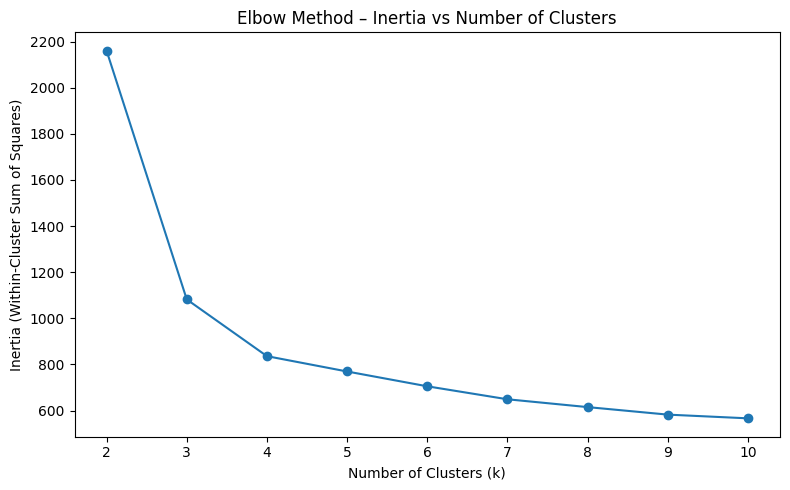

k=2 -> silhouette score = 0.474
k=3 -> silhouette score = 0.531
k=4 -> silhouette score = 0.430
k=5 -> silhouette score = 0.397
k=6 -> silhouette score = 0.324
k=7 -> silhouette score = 0.267
k=8 -> silhouette score = 0.230
k=9 -> silhouette score = 0.227
k=10 -> silhouette score = 0.214


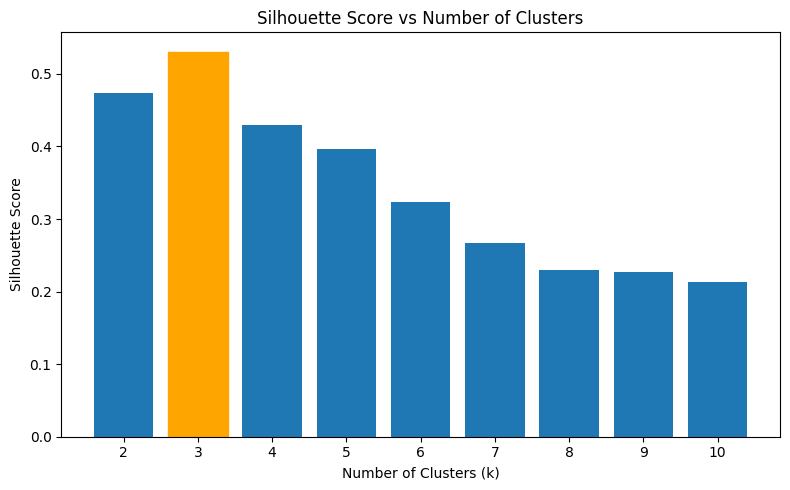

Best k by silhouette score: 3


In [ ]:
# 3.1
k_range = range(2, 11)
inertia_list = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_list.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia_list, marker='o')
plt.title("Elbow Method – Inertia vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig("elbow_plot.png")
plt.show()


# 3.2
sil_list = []
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_list.append(score)
    print(f"k={k} -> silhouette score = {score:.3f}")

best_k_sil = list(k_range)[np.argmax(sil_list)]

plt.figure(figsize=(8, 5))
bars = plt.bar(list(k_range), sil_list)

# highlighting best k
bars[np.argmax(sil_list)].set_color('orange')

plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig("silhouette_plot.png")
plt.show()

print(f"Best k by silhouette score: {best_k_sil}")


# 3.3
best_k = 3

Elbow plot: The inertia dropped sharply from k=2 to k=3, then decreased more slowly, which suggests an elbow around k=3.
Silhouette plot: The highest silhouette score was at k=3, meaning the clusters were most clearly separated at this value.
Conclusion: Both methods supported k=3, so 3 clusters is the best choice for this dataset

In [ ]:
#  SECTION 4 — TRAIN THE FINAL MODEL & VISUALISE CLUSTERS

Number of customers in each segment:
segment
0    120
1    270
2    110
Name: count, dtype: int64


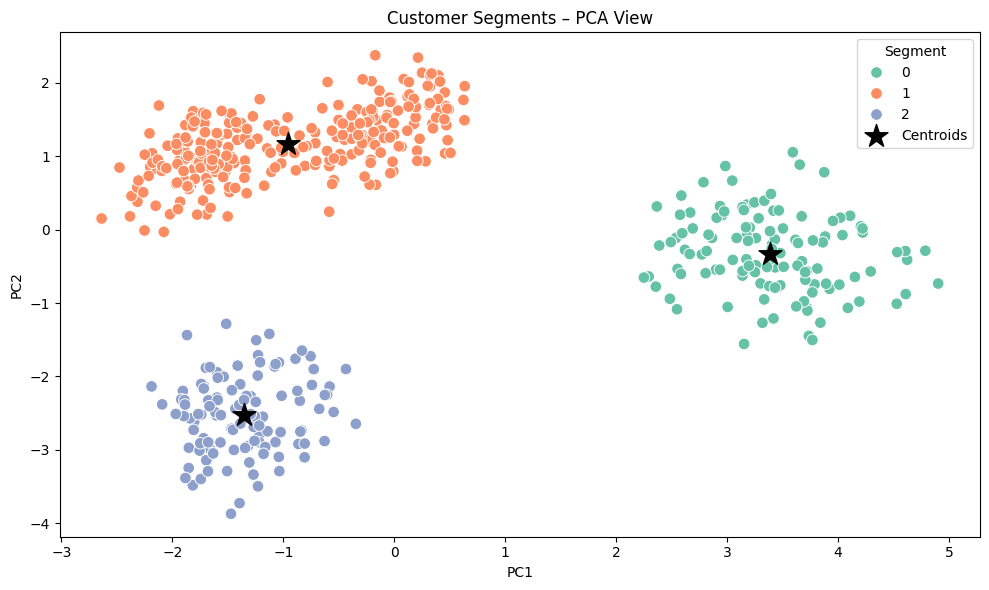

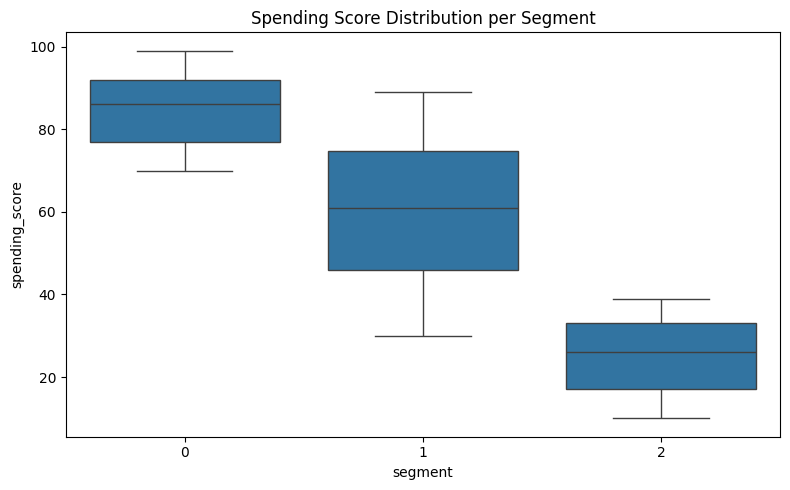

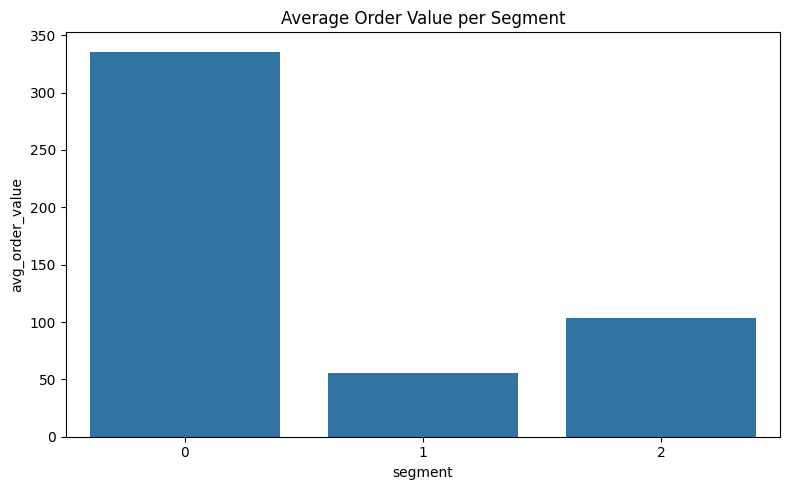

In [ ]:
# 4.1
# Training the final K-Means model using  best_k.
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["segment"] = final_model.fit_predict(X_scaled)

print("Number of customers in each segment:")
print(df["segment"].value_counts().sort_index())


# 4.2
# Visualising the clusters in 2-D PCA space.
# Scatter plot:
#   • x-axis : X_pca[:, 0]  (PC1)
#   • y-axis : X_pca[:, 1]  (PC2)
centroids_pca = pca.transform(final_model.cluster_centers_)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["segment"],
    palette="Set2",
    s=70
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="black",
    marker="*",
    s=300,
    label="Centroids"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments – PCA View")
plt.legend(title="Segment")
plt.tight_layout()
plt.savefig("cluster_pca_plot.png")
plt.show()



# 4.3
# Plot A — Box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x="segment", y="spending_score", data=df)
plt.title("Spending Score Distribution per Segment")
plt.tight_layout()
plt.savefig("boxplot_spending.png")
plt.show()

# Plot B — Bar chart
segment_avg_order = df.groupby("segment")["avg_order_value"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x="segment", y="avg_order_value", data=segment_avg_order)
plt.title("Average Order Value per Segment")
plt.tight_layout()
plt.savefig("barplot_order_value.png")
plt.show()

In [ ]:
#  SECTION 5 — SEGMENT ANALYSIS & CSV EXPORT

In [ ]:
# 5.1
segment_profile = df.groupby("segment")[feature_cols].mean()
segment_profile["customer_count"] = df["segment"].value_counts().sort_index()

print("Segment profile:")
print(segment_profile)


# 5.2
segment_names = {
    0: "High-Value Loyalists",
    1: "Bargain Hunters",
    2: "At-Risk Customers"
}

df["segment_name"] = df["segment"].map(segment_names)

print(df[["customer_id", "segment", "segment_name"]].head(12))


# 5.3
# File 1 — customer_segments.csv
df.to_csv("customer_segments.csv", index=False)
print(f"✓ customer_segments.csv saved ({len(df)} rows)")

# File 2 — segment_summary.csv
segment_summary = segment_profile.copy().reset_index()
segment_summary["segment_name"] = segment_summary["segment"].map(segment_names)

numeric_cols = segment_summary.select_dtypes(include=[np.number]).columns
segment_summary[numeric_cols] = segment_summary[numeric_cols].round(2)

segment_summary.to_csv("segment_summary.csv", index=False)
print(f"✓ segment_summary.csv saved ({len(segment_summary)} rows)")

Segment profile:
               age  annual_income  spending_score  purchase_freq  \
segment                                                            
0        47.058333  114538.333333       84.850000      40.391667   
1        30.003704   37995.185185       60.244444      19.151852   
2        53.409091   62963.636364       24.836364       5.554545   

         avg_order_value  loyalty_years  online_ratio  returns_rate  \
segment                                                               
0             335.792167       9.550000      0.771233      0.042983   
1              55.345926       1.725926      0.779441      0.135574   
2             103.869091       5.881818      0.271791      0.203027   

         customer_count  
segment                  
0                   120  
1                   270  
2                   110  
   customer_id  segment          segment_name
0        C0362        1       Bargain Hunters
1        C0074        0  High-Value Loyalists
2        C0375    

In [ ]:
#  SECTION 6 — POWER BI DATA VISUALISATION

In [ ]:
print(segment_profile)

               age  annual_income  spending_score  purchase_freq  \
segment                                                            
0        47.058333  114538.333333       84.850000      40.391667   
1        30.003704   37995.185185       60.244444      19.151852   
2        53.409091   62963.636364       24.836364       5.554545   

         avg_order_value  loyalty_years  online_ratio  returns_rate  \
segment                                                               
0             335.792167       9.550000      0.771233      0.042983   
1              55.345926       1.725926      0.779441      0.135574   
2             103.869091       5.881818      0.271791      0.203027   

         customer_count  
segment                  
0                   120  
1                   270  
2                   110  


In [ ]:
print("Highest annual_income:")
print(segment_profile["annual_income"].sort_values(ascending=False))

print("\nHighest avg_order_value:")
print(segment_profile["avg_order_value"].sort_values(ascending=False))

print("\nHighest spending_score:")
print(segment_profile["spending_score"].sort_values(ascending=False))

print("\nHighest purchase_freq:")
print(segment_profile["purchase_freq"].sort_values(ascending=False))

print("\nHighest loyalty_years:")
print(segment_profile["loyalty_years"].sort_values(ascending=False))

print("\nLowest returns_rate:")
print(segment_profile["returns_rate"].sort_values())

Highest annual_income:
segment
0    114538.333333
2     62963.636364
1     37995.185185
Name: annual_income, dtype: float64

Highest avg_order_value:
segment
0    335.792167
2    103.869091
1     55.345926
Name: avg_order_value, dtype: float64

Highest spending_score:
segment
0    84.850000
1    60.244444
2    24.836364
Name: spending_score, dtype: float64

Highest purchase_freq:
segment
0    40.391667
1    19.151852
2     5.554545
Name: purchase_freq, dtype: float64

Highest loyalty_years:
segment
0    9.550000
2    5.881818
1    1.725926
Name: loyalty_years, dtype: float64

Lowest returns_rate:
segment
0    0.042983
1    0.135574
2    0.203027
Name: returns_rate, dtype: float64


In [ ]:
print(segment_profile.loc[0])

age                    47.058333
annual_income      114538.333333
spending_score         84.850000
purchase_freq          40.391667
avg_order_value       335.792167
loyalty_years           9.550000
online_ratio            0.771233
returns_rate            0.042983
customer_count        120.000000
Name: 0, dtype: float64


In [ ]:
print(segment_profile.loc[1])
print(segment_profile.loc[2])

age                   30.003704
annual_income      37995.185185
spending_score        60.244444
purchase_freq         19.151852
avg_order_value       55.345926
loyalty_years          1.725926
online_ratio           0.779441
returns_rate           0.135574
customer_count       270.000000
Name: 1, dtype: float64
age                   53.409091
annual_income      62963.636364
spending_score        24.836364
purchase_freq          5.554545
avg_order_value      103.869091
loyalty_years          5.881818
online_ratio           0.271791
returns_rate           0.203027
customer_count       110.000000
Name: 2, dtype: float64
